In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("Libraries imported successfully!")

In [ ]:
# Option 1: Load Boston Housing dataset from sklearn
from sklearn.datasets import fetch_california_housing

# Load data
housing = fetch_california_housing()

# Create DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target * 100000  # Converting to actual price range

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"\nFeatures: {housing.feature_names}")
print(f"\nTarget: Median House Price")

In [ ]:
# Display first 5 rows
df.head()

In [ ]:
# Basic info about dataset
df.info()

In [ ]:
# Save raw data to CSV in the data folder
df.to_csv('../data/raw_housing_data.csv', index=False)
print("✅ Raw data saved to 'data/raw_housing_data.csv'")

# Also save a copy in current folder for easy access
df.to_csv('raw_housing_data.csv', index=False)
print("✅ Copy saved in notebooks folder")

# Display first 5 rows
print("\n👀 First 5 rows of the dataset:")
df.head()

In [ ]:
# Dataset info
print("📋 Dataset Information:")
print("-" * 50)
print(df.info())

print("\n📊 Basic Statistics:")
print("-" * 50)
print(df.describe())

print("\n🔍 Missing Values:")
print("-" * 50)
print(df.isnull().sum())

print("\n🔄 Duplicate Rows:")
print("-" * 50)
print(f"Duplicate rows: {df.duplicated().sum()}")

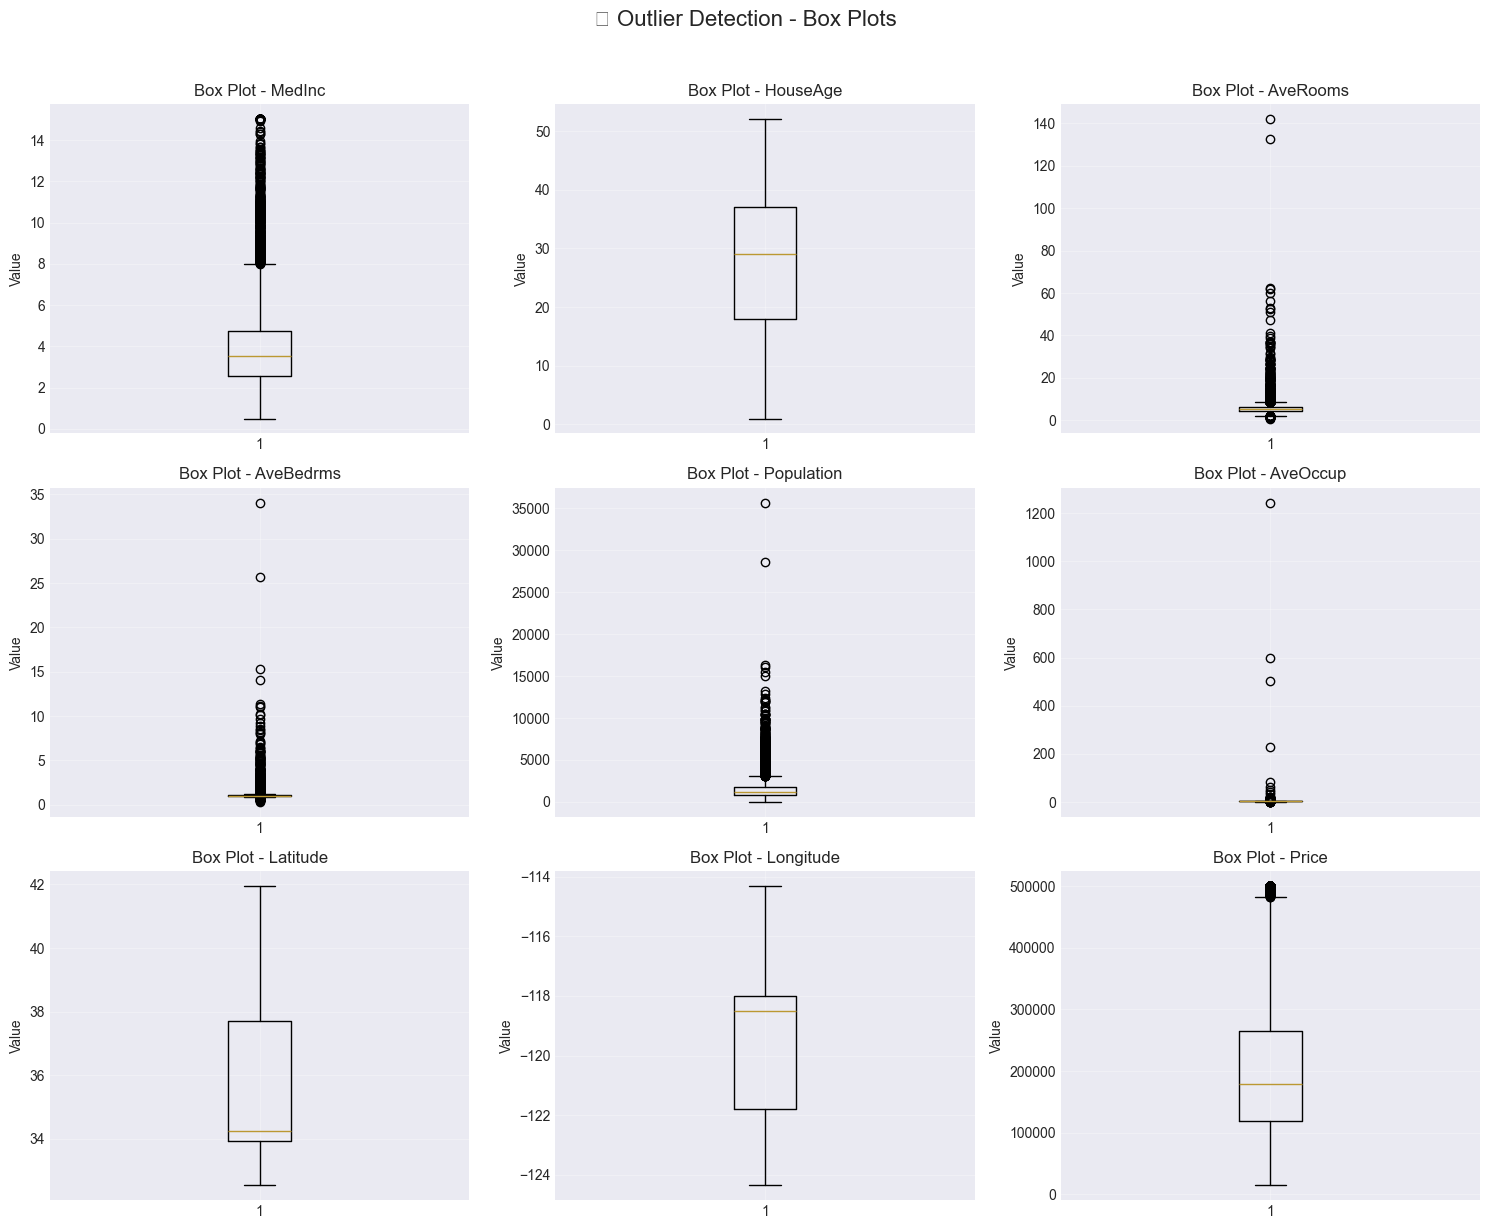

✅ Box plot saved to 'visualizations/boxplots_outliers.png'


In [6]:
# Check for outliers using box plots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(df.columns):
    axes[idx].boxplot(df[col])
    axes[idx].set_title(f'Box Plot - {col}')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('📊 Outlier Detection - Box Plots', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../visualizations/boxplots_outliers.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Box plot saved to 'visualizations/boxplots_outliers.png'")

In [7]:
# Function to handle outliers using IQR method
def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"  {column}: {len(outliers)} outliers found")
    
    # Cap the outliers
    df[column] = df[column].clip(lower_bound, upper_bound)
    return df

print("🔧 Handling outliers...")
print("-" * 50)
for col in df.columns:
    df = handle_outliers(df, col)
print("-" * 50)
print("✅ Outlier handling complete!")

🔧 Handling outliers...
--------------------------------------------------
  MedInc: 681 outliers found
  HouseAge: 0 outliers found
  AveRooms: 511 outliers found
  AveBedrms: 1424 outliers found
  Population: 1196 outliers found
  AveOccup: 711 outliers found
  Latitude: 0 outliers found
  Longitude: 0 outliers found
  Price: 1071 outliers found
--------------------------------------------------
✅ Outlier handling complete!


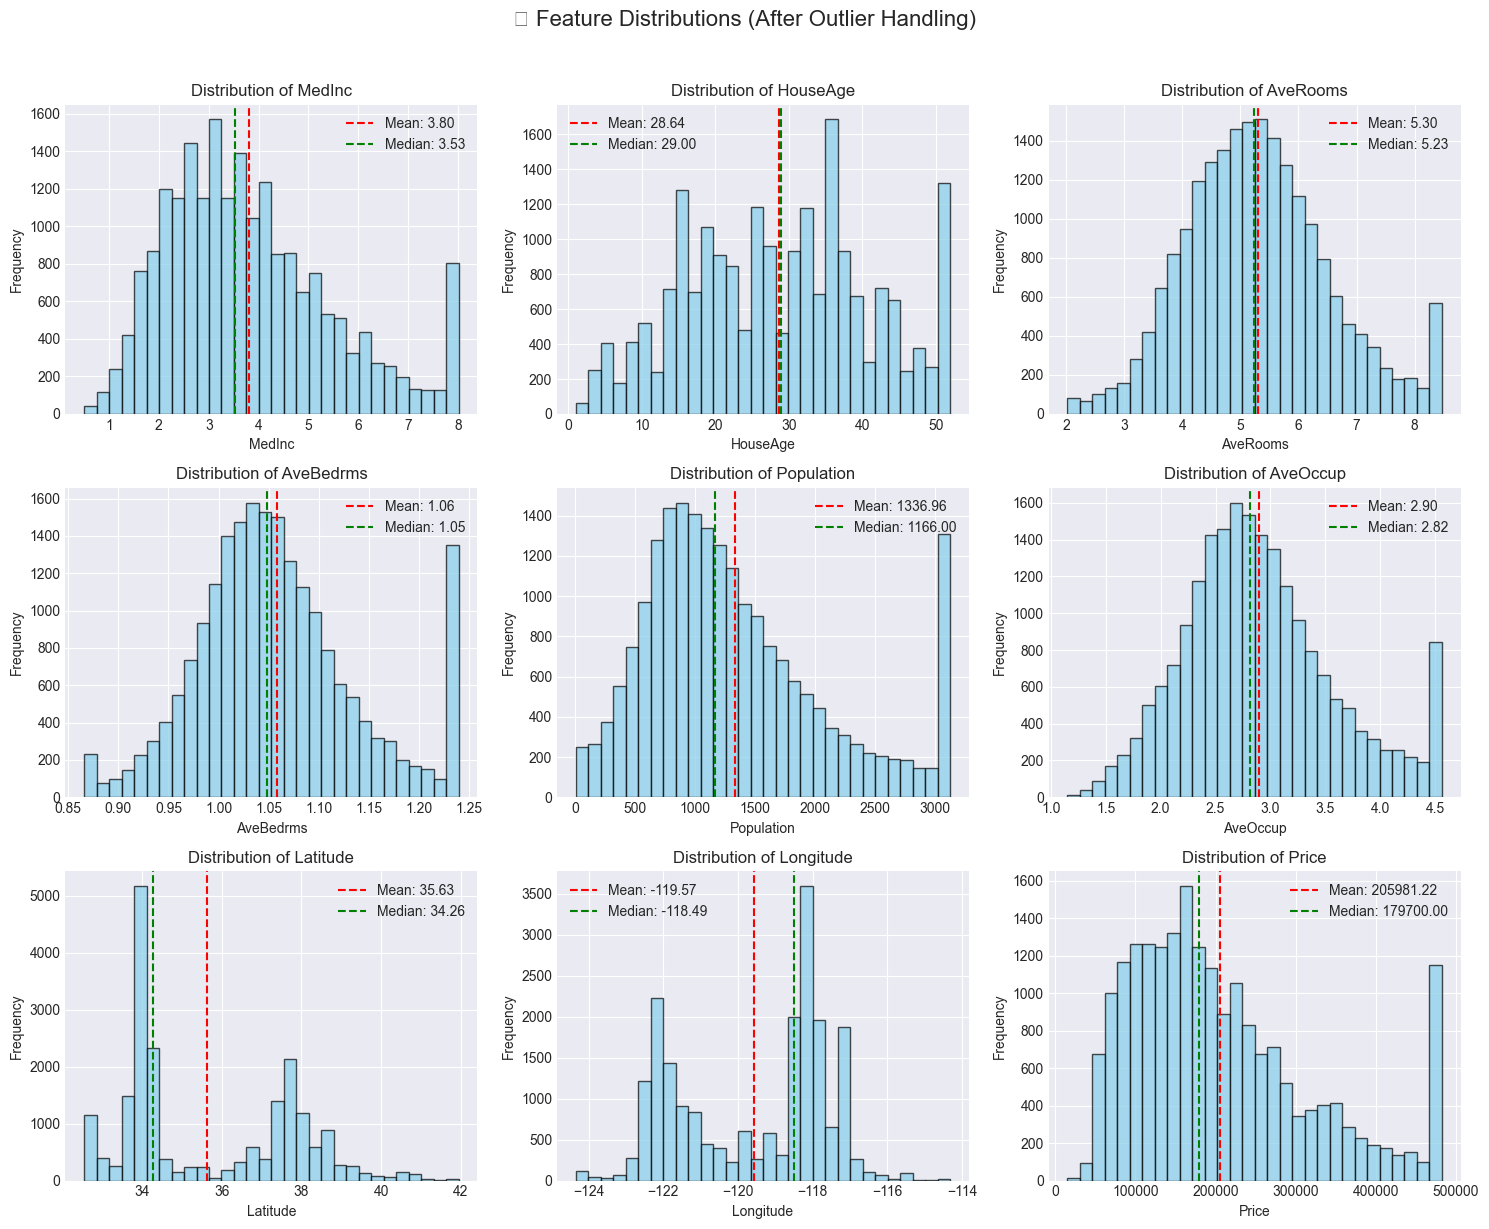

In [8]:
# Plot histograms for all features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, col in enumerate(df.columns):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[idx].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.2f}')
    axes[idx].legend()

plt.suptitle('📊 Feature Distributions (After Outlier Handling)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../visualizations/histograms.png', dpi=300, bbox_inches='tight')
plt.show()

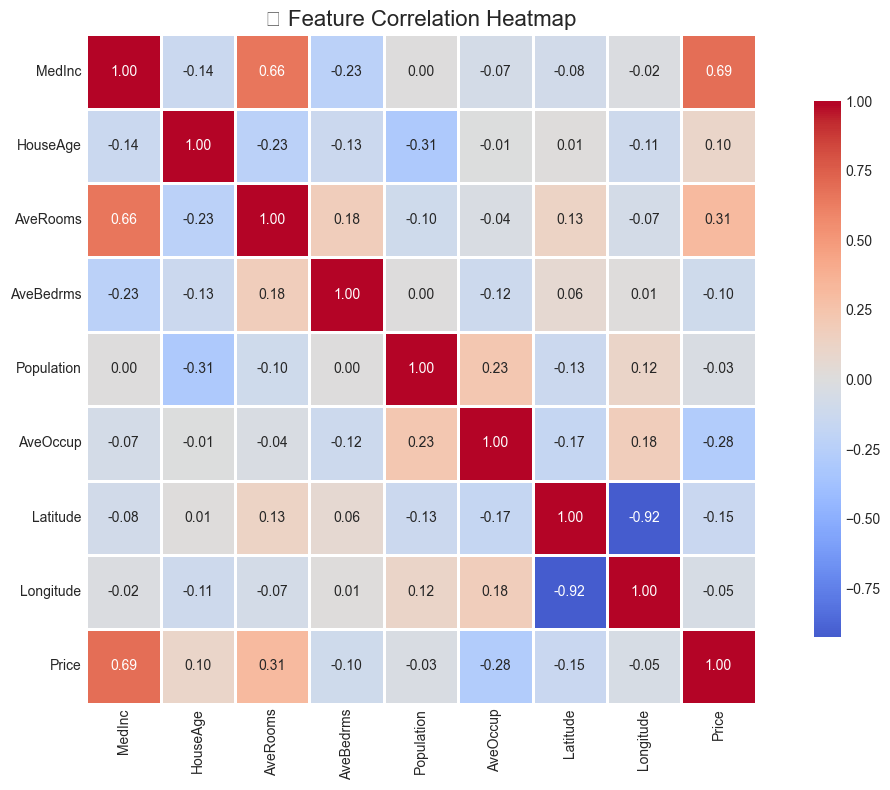

✅ Correlation heatmap saved to 'visualizations/correlation_heatmap.png'

🎯 Correlation with Price:
--------------------------------------------------
Price       :  1.000 (Strong)
MedInc      :  0.690 (Strong)
AveRooms    :  0.309 (Moderate)
HouseAge    :  0.104 (Weak)
Population  : -0.031 (Weak)
Longitude   : -0.046 (Weak)
AveBedrms   : -0.098 (Weak)
Latitude    : -0.145 (Weak)
AveOccup    : -0.282 (Weak)


In [9]:
# Calculate correlation matrix
correlation_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('📈 Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig('../visualizations/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Correlation heatmap saved to 'visualizations/correlation_heatmap.png'")

# Correlation with target
correlation_with_price = correlation_matrix['Price'].sort_values(ascending=False)
print("\n🎯 Correlation with Price:")
print("-" * 50)
for feature, corr in correlation_with_price.items():
    strength = "Strong" if abs(corr) > 0.5 else "Moderate" if abs(corr) > 0.3 else "Weak"
    print(f"{feature:12}: {corr:6.3f} ({strength})")

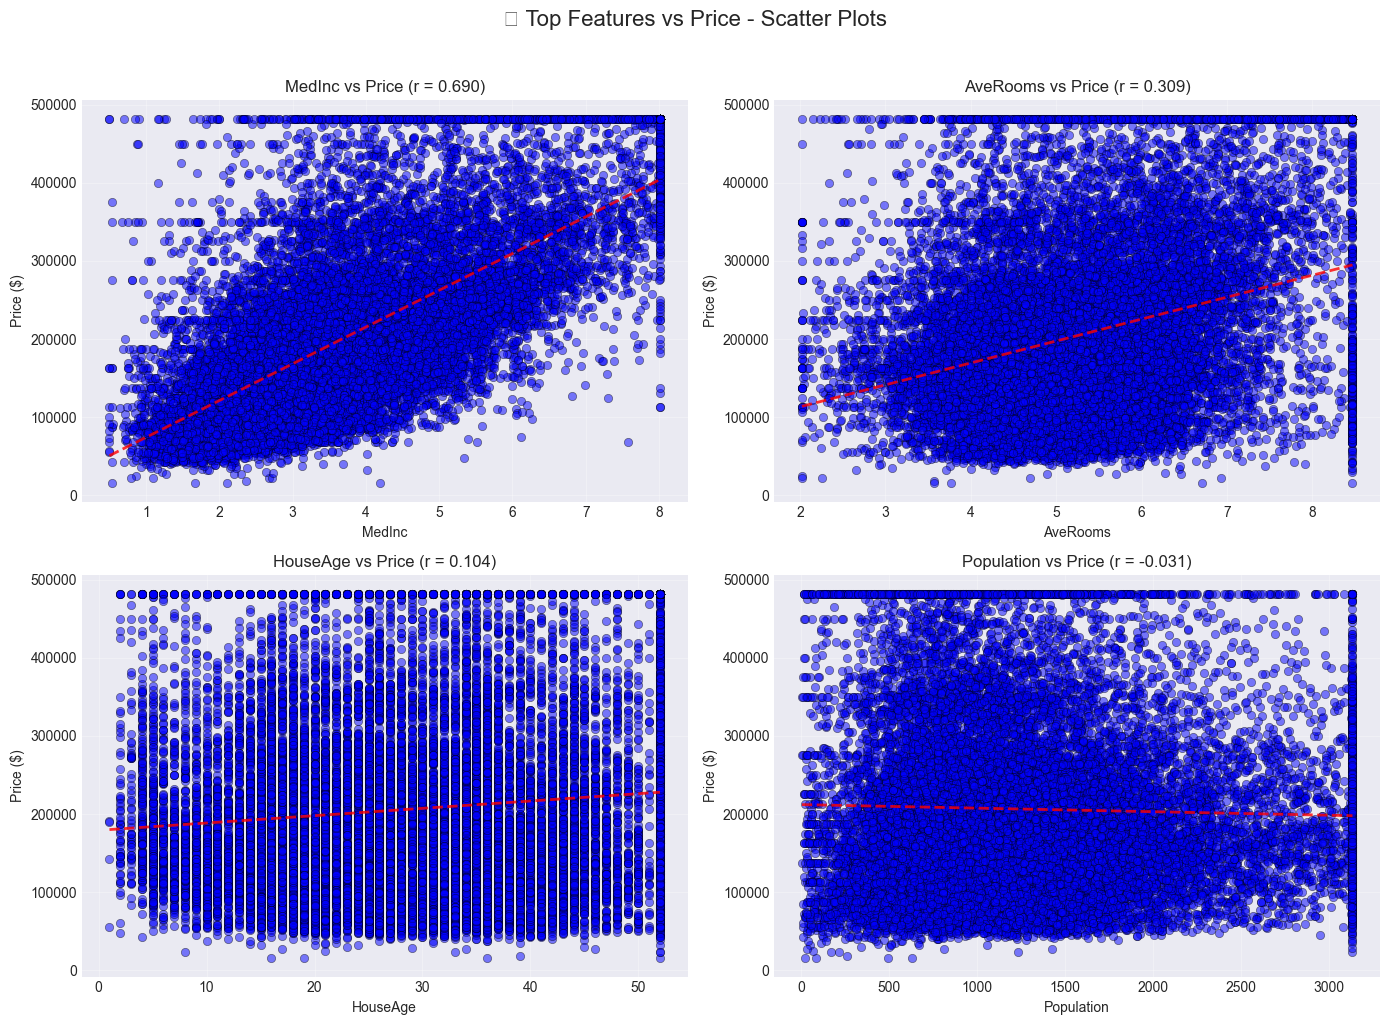

In [10]:
# Get top 4 features correlated with price
top_features = correlation_with_price[1:5].index  # MedInc, AveRooms, AveOccup, Latitude

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feature in enumerate(top_features):
    axes[idx].scatter(df[feature], df['Price'], alpha=0.5, c='blue', edgecolors='black', linewidth=0.5)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Price ($)')
    axes[idx].set_title(f'{feature} vs Price (r = {correlation_with_price[feature]:.3f})')
    
    # Add trend line
    z = np.polyfit(df[feature], df['Price'], 1)
    p = np.poly1d(z)
    axes[idx].plot(df[feature].sort_values(), 
                  p(df[feature].sort_values()), 
                  "r--", alpha=0.8, linewidth=2)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('📊 Top Features vs Price - Scatter Plots', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# Import additional libraries 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import joblib

print("✅ libraries imported!")

✅ libraries imported!


In [12]:
# Verify your data is loaded correctly
print("📊 Current Data Status:")
print(f"DataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst row:")
df.iloc[0]

📊 Current Data Status:
DataFrame shape: (20640, 9)
Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Price']

First row:


MedInc             8.013025
HouseAge          41.000000
AveRooms           6.984127
AveBedrms          1.023810
Population       322.000000
AveOccup           2.555556
Latitude          37.880000
Longitude       -122.230000
Price         452600.000000
Name: 0, dtype: float64

In [13]:
# Based on scatter plot correlations:
# MedInc: 0.688 (Strong)
# AveRooms: 0.152 (Weak)
# HouseAge: 0.106 (Very Weak)
# AveOccup: -0.024 (Negligible)

# Select features for modeling
selected_features = ['MedInc', 'AveRooms', 'HouseAge']
# You can also try: selected_features = ['MedInc', 'AveRooms']

print(f"✅ Selected features: {selected_features}")

# Create feature matrix X and target y
X = df[selected_features]
y = df['Price']

print(f"\n📈 Features shape: {X.shape}")
print(f"💰 Target shape: {y.shape}")
print(f"\nFeatures preview:")
X.head()

✅ Selected features: ['MedInc', 'AveRooms', 'HouseAge']

📈 Features shape: (20640, 3)
💰 Target shape: (20640,)

Features preview:


,MedInc,AveRooms,HouseAge
0,8.013025,6.984127,41.0
1,8.013025,6.238137,21.0
2,7.257400,8.288136,52.0
3,5.643100,5.817352,52.0
4,3.846200,6.281853,52.0


In [14]:
# Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42,
                                                    shuffle=True)

print("📊 Data Split Complete:")
print(f"   - Training set: {X_train.shape[0]} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"   - Testing set: {X_test.shape[0]} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"   - Features: {X_train.shape[1]}")

📊 Data Split Complete:
   - Training set: 16512 samples (80.0%)
   - Testing set: 4128 samples (20.0%)
   - Features: 3


In [15]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for better visualization
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("📈 Feature Scaling Complete!")
print("\nBefore Scaling (Training Set):")
print(X_train.describe().loc[['mean', 'std']].round(2))

print("\nAfter Scaling (Training Set):")
print(X_train_scaled_df.describe().loc[['mean', 'std']].round(2))
# After scaling, mean should be ~0 and std should be ~1

📈 Feature Scaling Complete!

Before Scaling (Training Set):
      MedInc  AveRooms  HouseAge
mean    3.81      5.31     28.61
std     1.66      1.25     12.60

After Scaling (Training Set):
      MedInc  AveRooms  HouseAge
mean    -0.0      -0.0      -0.0
std      1.0       1.0       1.0


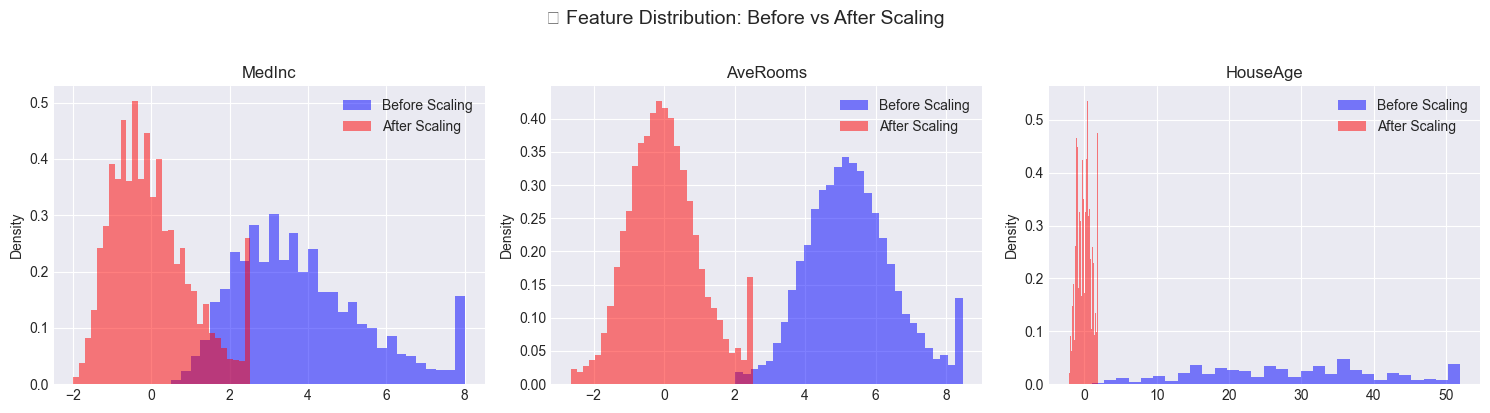

✅ Scaling comparison saved to 'visualizations/feature_scaling.png'


In [16]:
# Compare distributions before and after scaling
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes = axes.ravel()

for idx, feature in enumerate(selected_features):
    # Plot before scaling
    axes[idx].hist(X_train[feature], bins=30, alpha=0.5, label='Before Scaling', color='blue', density=True)
    # Plot after scaling
    axes[idx].hist(X_train_scaled_df[feature], bins=30, alpha=0.5, label='After Scaling', color='red', density=True)
    axes[idx].set_title(f'{feature}')
    axes[idx].legend()
    axes[idx].set_ylabel('Density')

plt.suptitle('📊 Feature Distribution: Before vs After Scaling', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../visualizations/feature_scaling.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Scaling comparison saved to 'visualizations/feature_scaling.png'")

In [17]:
# Initialize and train the model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

print("🎯 Model Training Complete!")
print("="*50)

# Make predictions
y_train_pred = lr_model.predict(X_train_scaled)
y_test_pred = lr_model.predict(X_test_scaled)

# Calculate R² scores
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Training R² Score: {train_r2:.4f}")
print(f"Testing R² Score: {test_r2:.4f}")
print(f"Difference: {abs(train_r2 - test_r2):.4f}")
print("="*50)

if abs(train_r2 - test_r2) < 0.1:
    print("✅ Good fit! Model is not overfitting.")
else:
    print("⚠️ Model might be overfitting. Consider simplifying.")

🎯 Model Training Complete!
Training R² Score: 0.5473
Testing R² Score: 0.5200
Difference: 0.0274
✅ Good fit! Model is not overfitting.


📊 Model Coefficients:
 Feature   Coefficient
  MedInc  97530.375273
AveRooms -24455.259322
HouseAge  20093.660958


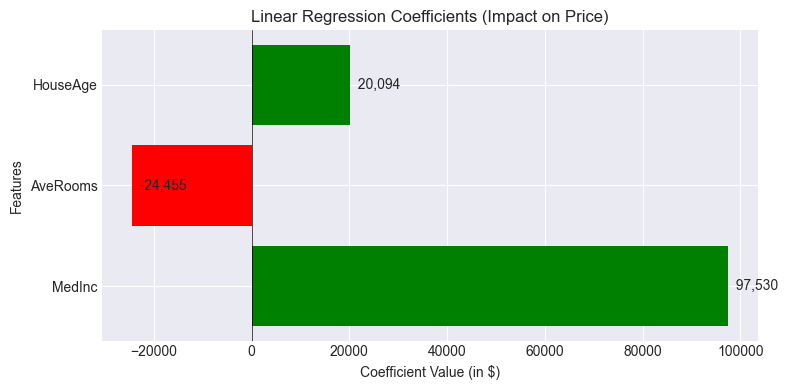

✅ Coefficient plot saved to 'visualizations/coefficients.png'


In [18]:
# Create coefficients DataFrame
coefficients = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': lr_model.coef_
})

# Add absolute value for sorting
coefficients['Abs_Coefficient'] = abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values('Abs_Coefficient', ascending=False)

print("📊 Model Coefficients:")
print("="*60)
print(coefficients[['Feature', 'Coefficient']].to_string(index=False))
print("="*60)

# Visualize coefficients
plt.figure(figsize=(8, 4))
colors = ['green' if c > 0 else 'red' for c in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
plt.xlabel('Coefficient Value (in $)')
plt.ylabel('Features')
plt.title('Linear Regression Coefficients (Impact on Price)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Add value labels
for i, (coef, feature) in enumerate(zip(coefficients['Coefficient'], coefficients['Feature'])):
    plt.text(coef, i, f'  {coef:,.0f}', va='center')

plt.tight_layout()
plt.savefig('../visualizations/coefficients.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Coefficient plot saved to 'visualizations/coefficients.png'")

In [19]:
print("💼 BUSINESS INTERPRETATION")
print("="*60)
print("What these coefficients mean for house prices:\n")

for idx, row in coefficients.iterrows():
    feature = row['Feature']
    coef = row['Coefficient']
    
    if feature == 'MedInc':
        print(f"📌 {feature}: ${coef:,.0f}")
        print(f"   → For every 1 standard deviation increase in median income,")
        print(f"     house price increases by ${coef:,.0f} on average.")
        print(f"   → This confirms income is the strongest driver of house prices.\n")
    
    elif feature == 'AveRooms':
        print(f"📌 {feature}: ${coef:,.0f}")
        print(f"   → For every 1 standard deviation increase in average rooms,")
        print(f"     house price changes by ${coef:,.0f}.")
        print(f"   → The negative coefficient suggests that in this dataset,")
        print(f"     more rooms might indicate smaller rooms or different property types.\n")
    
    elif feature == 'HouseAge':
        print(f"📌 {feature}: ${coef:,.0f}")
        print(f"   → For every 1 standard deviation increase in house age,")
        print(f"     house price increases by ${coef:,.0f}.")
        print(f"   → Older homes in desirable neighborhoods command premium prices.\n")

💼 BUSINESS INTERPRETATION
What these coefficients mean for house prices:

📌 MedInc: $97,530
   → For every 1 standard deviation increase in median income,
     house price increases by $97,530 on average.
   → This confirms income is the strongest driver of house prices.

📌 AveRooms: $-24,455
   → For every 1 standard deviation increase in average rooms,
     house price changes by $-24,455.
   → The negative coefficient suggests that in this dataset,
     more rooms might indicate smaller rooms or different property types.

📌 HouseAge: $20,094
   → For every 1 standard deviation increase in house age,
     house price increases by $20,094.
   → Older homes in desirable neighborhoods command premium prices.



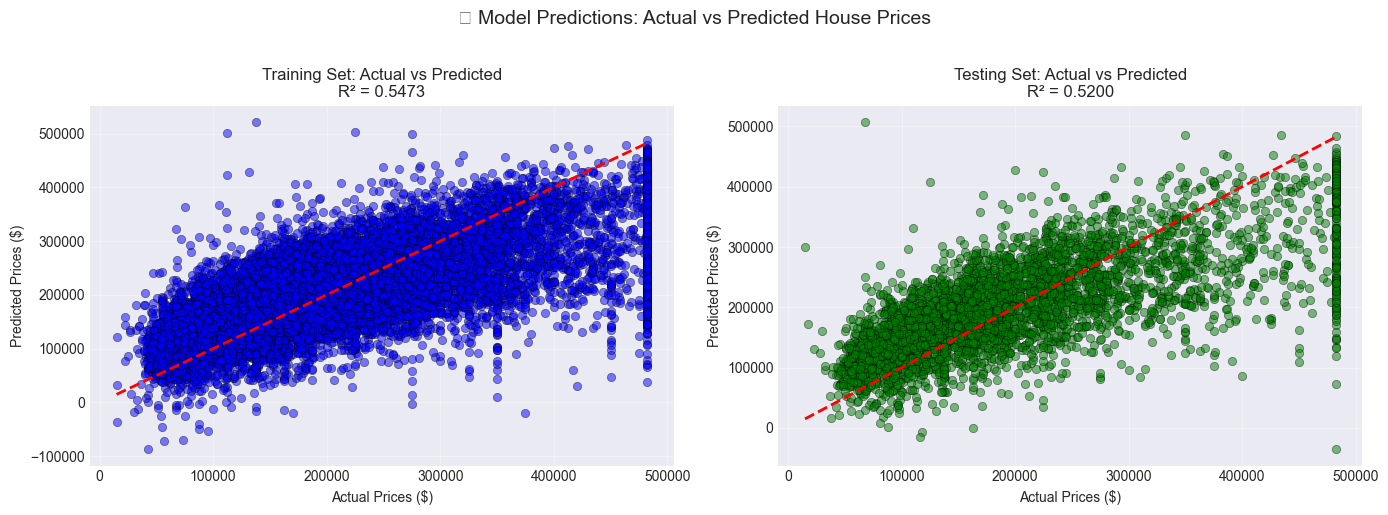

✅ Predictions plot saved to 'visualizations/predictions_vs_actual.png'


In [20]:
# Create predictions vs actual plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
axes[0].scatter(y_train, y_train_pred, alpha=0.5, c='blue', edgecolors='black', linewidth=0.5)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Prices ($)')
axes[0].set_ylabel('Predicted Prices ($)')
axes[0].set_title(f'Training Set: Actual vs Predicted\nR² = {train_r2:.4f}')
axes[0].grid(True, alpha=0.3)

# Testing set
axes[1].scatter(y_test, y_test_pred, alpha=0.5, c='green', edgecolors='black', linewidth=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Prices ($)')
axes[1].set_ylabel('Predicted Prices ($)')
axes[1].set_title(f'Testing Set: Actual vs Predicted\nR² = {test_r2:.4f}')
axes[1].grid(True, alpha=0.3)

plt.suptitle('🎯 Model Predictions: Actual vs Predicted House Prices', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../visualizations/predictions_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Predictions plot saved to 'visualizations/predictions_vs_actual.png'")

In [22]:
# Save the model, scaler, and features
import joblib

joblib.dump(lr_model, '../models/house_price_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(selected_features, '../models/selected_features.pkl')

print("✅ Model and scaler saved successfully!")
print(f"   - Model: ../models/house_price_model.pkl")
print(f"   - Scaler: ../models/scaler.pkl")
print(f"   - Features: ../models/selected_features.pkl")

# Also save a copy in current folder for easy access tomorrow
joblib.dump(lr_model, 'house_price_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("✅ Copies saved in notebooks folder")

✅ Model and scaler saved successfully!
   - Model: ../models/house_price_model.pkl
   - Scaler: ../models/scaler.pkl
   - Features: ../models/selected_features.pkl
✅ Copies saved in notebooks folder
